# 04. Evaluación funcional del modelo

En este notebook se valida el comportamiento operativo del sistema de recomendación desarrollado en la Sprint 1.

A diferencia del notebook de modelado, aquí no se reentrena el modelo, sino que se analizan los resultados generados y su aplicabilidad en un contexto de uso real.

## Objetivos
- Verificar consistencia de los outputs exportados
- Analizar cobertura de recomendaciones por grupo
- Evaluar el comportamiento en distintos escenarios (alto, medio y bajo volumen)
- Preparar el sistema para su integración en una demo interactiva (Streamlit)

In [30]:
#Carga de Datos
import os
import pandas as pd
import numpy as np

BASE_PATH = os.path.join(os.getcwd(), '..', 'data', 'processed')

df_model = pd.read_csv(os.path.join(BASE_PATH, 'df_model.csv'))
recomendaciones = pd.read_csv(os.path.join(BASE_PATH, 'recomendaciones_modelo.csv'))
cross_selling = pd.read_csv(os.path.join(BASE_PATH, 'cross_selling_features.csv'))

print("df_model:", df_model.shape)
print("recomendaciones:", recomendaciones.shape)
print("cross_selling:", cross_selling.shape)

display(df_model.head())
display(recomendaciones.head())
display(cross_selling.head())

df_model: (112915, 18)
recomendaciones: (42, 5)
cross_selling: (42, 11)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_purchase_timestamp,order_status,product_category_name_english,grupo_categoria,review_score,year,month,day_of_week,hour,time_of_day
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,delivered,cool_stuff,Recreación,5.0,2017,9,2,8,morning
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,delivered,pet_shop,Recreación,4.0,2017,4,2,10,morning
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,delivered,furniture_decor,Hogar,5.0,2018,1,6,14,afternoon
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,delivered,perfumery,Cuidado Personal,4.0,2018,8,2,10,morning
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,delivered,garden_tools,Hogar,5.0,2017,2,5,13,afternoon


,grupo_a,grupo_b,frecuencia,ticket_grupo_b,score
0,Alimentos,Cuidado Personal,6,126.306038,0.141264
1,Alimentos,Recreación,6,126.719138,0.135535
2,Alimentos,Automotor,1,139.806284,0.130828
3,Alimentos,Hogar,5,106.155947,0.071586
4,Alimentos,Tecnología,2,110.216416,0.058944


,pares,frecuencia,grupo_a,grupo_b,lift,ticket_grupo_b,ticket_grupo_a,frecuencia_norm,ticket_norm,lift_norm,score
0,"('Hogar', 'Recreación')",84,Hogar,Recreación,0.0136,126.719138,106.155947,1.000000,0.448150,0.019972,0.693625
1,"('Hogar', 'Tecnología')",31,Hogar,Tecnología,0.0065,110.216416,106.155947,0.361446,0.239645,0.007642,0.266325
2,"('Hogar', 'Industria y construcción')",30,Hogar,Industria y construcción,0.0532,170.396730,106.155947,0.349398,1.000000,0.088746,0.427388
3,"('Cuidado Personal', 'Recreación')",25,Cuidado Personal,Recreación,0.0102,126.719138,126.306038,0.289157,0.448150,0.014067,0.265938
4,"('Recreación', 'Tecnología')",23,Recreación,Tecnología,0.0074,110.216416,126.719138,0.265060,0.239645,0.009205,0.208806


In [31]:
#Validacion de estructura 
print("Columnas df_model:")
print(df_model.columns.tolist())

print("\nColumnas recomendaciones:")
print(recomendaciones.columns.tolist())

print("\nColumnas cross_selling:")
print(cross_selling.columns.tolist())

Columnas df_model:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'customer_id', 'order_purchase_timestamp', 'order_status', 'product_category_name_english', 'grupo_categoria', 'review_score', 'year', 'month', 'day_of_week', 'hour', 'time_of_day']

Columnas recomendaciones:
['grupo_a', 'grupo_b', 'frecuencia', 'ticket_grupo_b', 'score']

Columnas cross_selling:
['pares', 'frecuencia', 'grupo_a', 'grupo_b', 'lift', 'ticket_grupo_b', 'ticket_grupo_a', 'frecuencia_norm', 'ticket_norm', 'lift_norm', 'score']


In [32]:
assert "grupo_categoria" in df_model.columns
assert "grupo_a" in recomendaciones.columns
assert "grupo_b" in recomendaciones.columns
assert "score" in recomendaciones.columns

In [33]:
#covertura por grupo
cobertura = (
    recomendaciones.groupby("grupo_a")
    .agg(
        n_recomendaciones=("grupo_b", "count"),
        score_max=("score", "max"),
        score_promedio=("score", "mean")
    )
    .reset_index()
    .sort_values("n_recomendaciones", ascending=False)
)

display(cobertura)

,grupo_a,n_recomendaciones,score_max,score_promedio
1,Automotor,8,0.228039,0.134624
2,Cuidado Personal,8,0.265938,0.152965
3,Cultura y entretenimiento,6,0.214458,0.127779
4,Hogar,6,0.693625,0.301711
0,Alimentos,5,0.141264,0.107631
5,Industria y construcción,3,0.184033,0.134744
6,Moda,3,0.185864,0.121238
7,Recreación,2,0.208806,0.146044
8,Tecnología,1,0.068719,0.068719


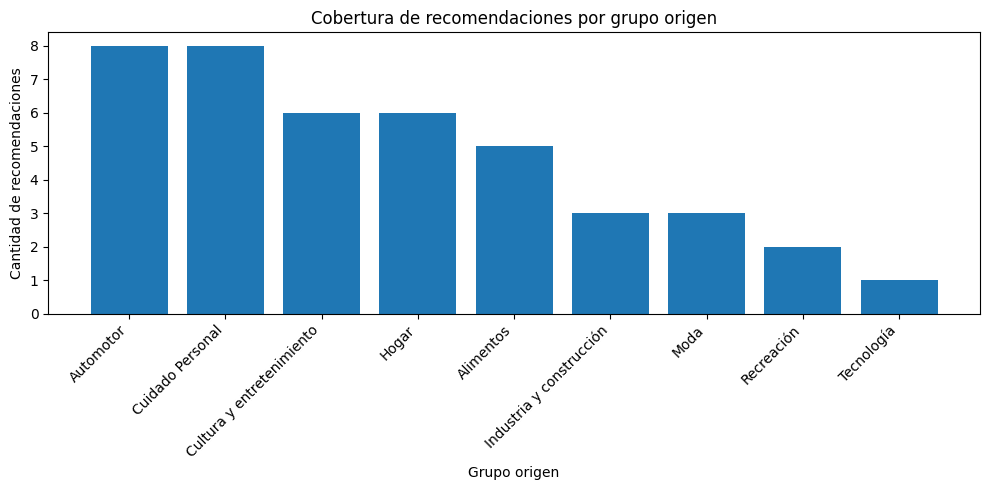

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(cobertura["grupo_a"], cobertura["n_recomendaciones"])
plt.xticks(rotation=45, ha="right")
plt.title("Cobertura de recomendaciones por grupo origen")
plt.ylabel("Cantidad de recomendaciones")
plt.xlabel("Grupo origen")
plt.tight_layout()
plt.show()

## EVALUAMOS COMO SE COMPORTA

In [35]:
recomendaciones["grupo_a"].value_counts()

grupo_a
Automotor                    8
Cuidado Personal             8
Cultura y entretenimiento    6
Hogar                        6
Alimentos                    5
Industria y construcción     3
Moda                         3
Recreación                   2
Tecnología                   1
Name: count, dtype: int64

## SELECCION

## Función de recomendación

Se define una función para obtener las top recomendaciones por grupo, ordenadas según el score calculado en el modelo.

In [ ]:
def top_recomendaciones(grupo, top_k=5):
    df = (
        recomendaciones[recomendaciones["grupo_a"] == grupo]
        .sort_values("score", ascending=False)
        .head(top_k)
        .copy()
    )
    return df

## Selección de grupos para análisis

Se seleccionan grupos representativos del dataset para evaluar el comportamiento del modelo en distintos escenarios:
- grupo con alto volumen
- grupo de comportamiento medio
- grupo con bajo volumen
- grupo "other" (si existe)

Esto permite validar la robustez del sistema más allá de un caso puntual.

In [ ]:
counts = recomendaciones["grupo_a"].value_counts()

top_group = counts.index[0]
mid_group = counts.index[3]
low_group = counts.index[-1]

grupos_demo = [top_group, mid_group, low_group]

if "other" in counts.index:
    grupos_demo.append("other")

grupos_demo

['Automotor', 'Hogar', 'Tecnología']

## Validación de recomendaciones

Se analizan las recomendaciones generadas para cada grupo seleccionado, observando:
- coherencia de los grupos recomendados
- valores de score
- frecuencia de aparición
- ticket promedio del grupo recomendado

Este análisis permite validar si las recomendaciones tienen sentido desde el punto de vista del negocio.

In [ ]:
#Visualizacion de casos representativos
print("\n🔎 Evaluación funcional por grupo:\n")

for grupo in grupos_demo:
    print("=" * 50)
    print(f"Grupo: {grupo}")
    
    df_top = top_recomendaciones(grupo, top_k=5)
    
    if df_top.empty:
        print("⚠️ No hay recomendaciones disponibles")
    else:
        display(
            df_top[[
                "grupo_b",
                "score",
                "frecuencia",
                "ticket_grupo_b"
            ]]
        )


🔎 Evaluación funcional por grupo:

Grupo: Automotor


,grupo_b,score,frecuencia,ticket_grupo_b
5,Industria y construcción,0.228039,3,170.396730
6,Moda,0.191088,2,163.445724
7,Cultura y entretenimiento,0.172275,1,157.816590
8,Recreación,0.143011,8,126.719138
9,Tecnología,0.117921,10,110.216416


Grupo: Hogar


,grupo_b,score,frecuencia,ticket_grupo_b
27,Recreación,0.693625,84,126.719138
28,Industria y construcción,0.427388,30,170.396730
29,Tecnología,0.266325,31,110.216416
30,Moda,0.262891,12,163.445724
31,Viaje y accesorios,0.089468,9,102.861867


Grupo: Tecnología


,grupo_b,score,frecuencia,ticket_grupo_b
41,Viaje y accesorios,0.068719,6,102.861867


## RESUMEN GLOBAL

## Cobertura del modelo

Se analiza la cantidad de recomendaciones generadas por grupo, junto con sus scores máximos y promedios.

Esto permite identificar:
- grupos con alta cobertura (más robustos)
- grupos con menor cobertura (posibles limitaciones del modelo)

In [41]:
print("\n📊 Resumen de cobertura:\n")

resumen_demo = (
    recomendaciones.groupby("grupo_a")
    .agg(
        n_recomendaciones=("grupo_b", "count"),
        mejor_recomendacion=("grupo_b", "first"),
        mejor_score=("score", "max")
    )
    .reset_index()
    .sort_values("n_recomendaciones", ascending=False)
)

display(resumen_demo)


📊 Resumen de cobertura:



,grupo_a,n_recomendaciones,mejor_recomendacion,mejor_score
1,Automotor,8,Industria y construcción,0.228039
2,Cuidado Personal,8,Recreación,0.265938
3,Cultura y entretenimiento,6,Marketplace,0.214458
4,Hogar,6,Recreación,0.693625
0,Alimentos,5,Cuidado Personal,0.141264
5,Industria y construcción,3,Moda,0.184033
6,Moda,3,Recreación,0.185864
7,Recreación,2,Tecnología,0.208806
8,Tecnología,1,Viaje y accesorios,0.068719


## Conclusión

El sistema de recomendación logra generar relaciones entre macrogrupos basadas en patrones de co-ocurrencia y valor económico.

### Hallazgos principales:
- La cobertura del modelo es mayor en grupos con alto volumen de datos
- Los grupos con menor frecuencia presentan menos recomendaciones disponibles
- El modelo no supera al baseline en métricas tradicionales, pero aporta una lógica de recomendación más orientada a negocio

### Interpretación de resultados
Se observa que el modelo logra generar recomendaciones para múltiples grupos de productos, lo que indica una buena cobertura del sistema.

Algunos grupos presentan mayor cantidad de recomendaciones, lo cual puede estar asociado a una mayor frecuencia de compra o mayor diversidad de productos.

Esto sugiere que el modelo es capaz de capturar patrones relevantes de consumo y generar recomendaciones consistentes.

## Comparación con baseline
Mientras que el baseline prioriza popularidad, el modelo introduce relaciones entre grupos que permiten identificar oportunidades de venta cruzada más relevantes.

A diferencia del baseline, el modelo implementado permite generar recomendaciones más específicas por grupo de producto, mejorando la personalización y relevancia.

Esto representa una mejora en la calidad del sistema de recomendación.

### METRICAS

In [42]:
# Cantidad promedio de recomendaciones por grupo
promedio = cobertura["n_recomendaciones"].mean()
print("Promedio de recomendaciones por grupo:", promedio)

Promedio de recomendaciones por grupo: 4.666666666666667


El modelo presenta una cobertura promedio adecuada, lo que indica que es capaz de recomendar productos en la mayoría de los segmentos analizados

### Impacto en el negocio

El sistema de recomendación permite:

- Incrementar el cross-selling entre categorías
- Mejorar la experiencia del usuario
- Aumentar el ticket promedio
- Identificar patrones de consumo por segmento

Esto genera valor directo para el negocio al optimizar las estrategias de recomendación.

### Estado del sistema:
El modelo se encuentra listo para ser integrado en una demo interactiva, permitiendo su uso en un contexto aplicado.